# EDA sociologique & électorale — 2007 · 2013 · 2019

Hypothèses : (1) vote/abstention dépendent de facteurs sociaux, économiques, territoriaux ;
(2) clivage urbain/rural structurant ; (3) structures persistantes dans le temps.


In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath('../..'))
import src.eda_utils as eu
from src.features_insee import charger_tables, construire_features

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"axes.titlesize": 16, "axes.labelsize": 13,
                     "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 12})

# Palettes : tons bleu-vert + accents (pas monochromes)
CMAP_SEQ   = "mako"                          # heatmaps de profil (séquentiel bleu-vert)
CMAP_CORR  = "vlag"                          # corrélations (divergent bleu-rouge)
PAL_ANNEES = sns.color_palette("deep")[:3]   # 2007/2013/2019 : 3 couleurs distinctes
PAL_STRATE = sns.color_palette("crest", 4)   # strates rural→ville (dégradé ordonné)

A = {}
for an in (2007, 2013, 2019):
    A[an] = eu.stratifier(eu.nettoyer(construire_features(charger_tables(an), an)))
    print(f"{an} : {A[an].shape[0]:,} communes")

2007 : 36,676 communes
2013 : 36,635 communes
2019 : 34,932 communes


Structure sociale des territoires

Profil social par strate urbaine (comparaison des trois années)
*Les trois heatmaps sont empilées et partagent la même échelle : on lit d'un coup ce qui bouge ou non.*

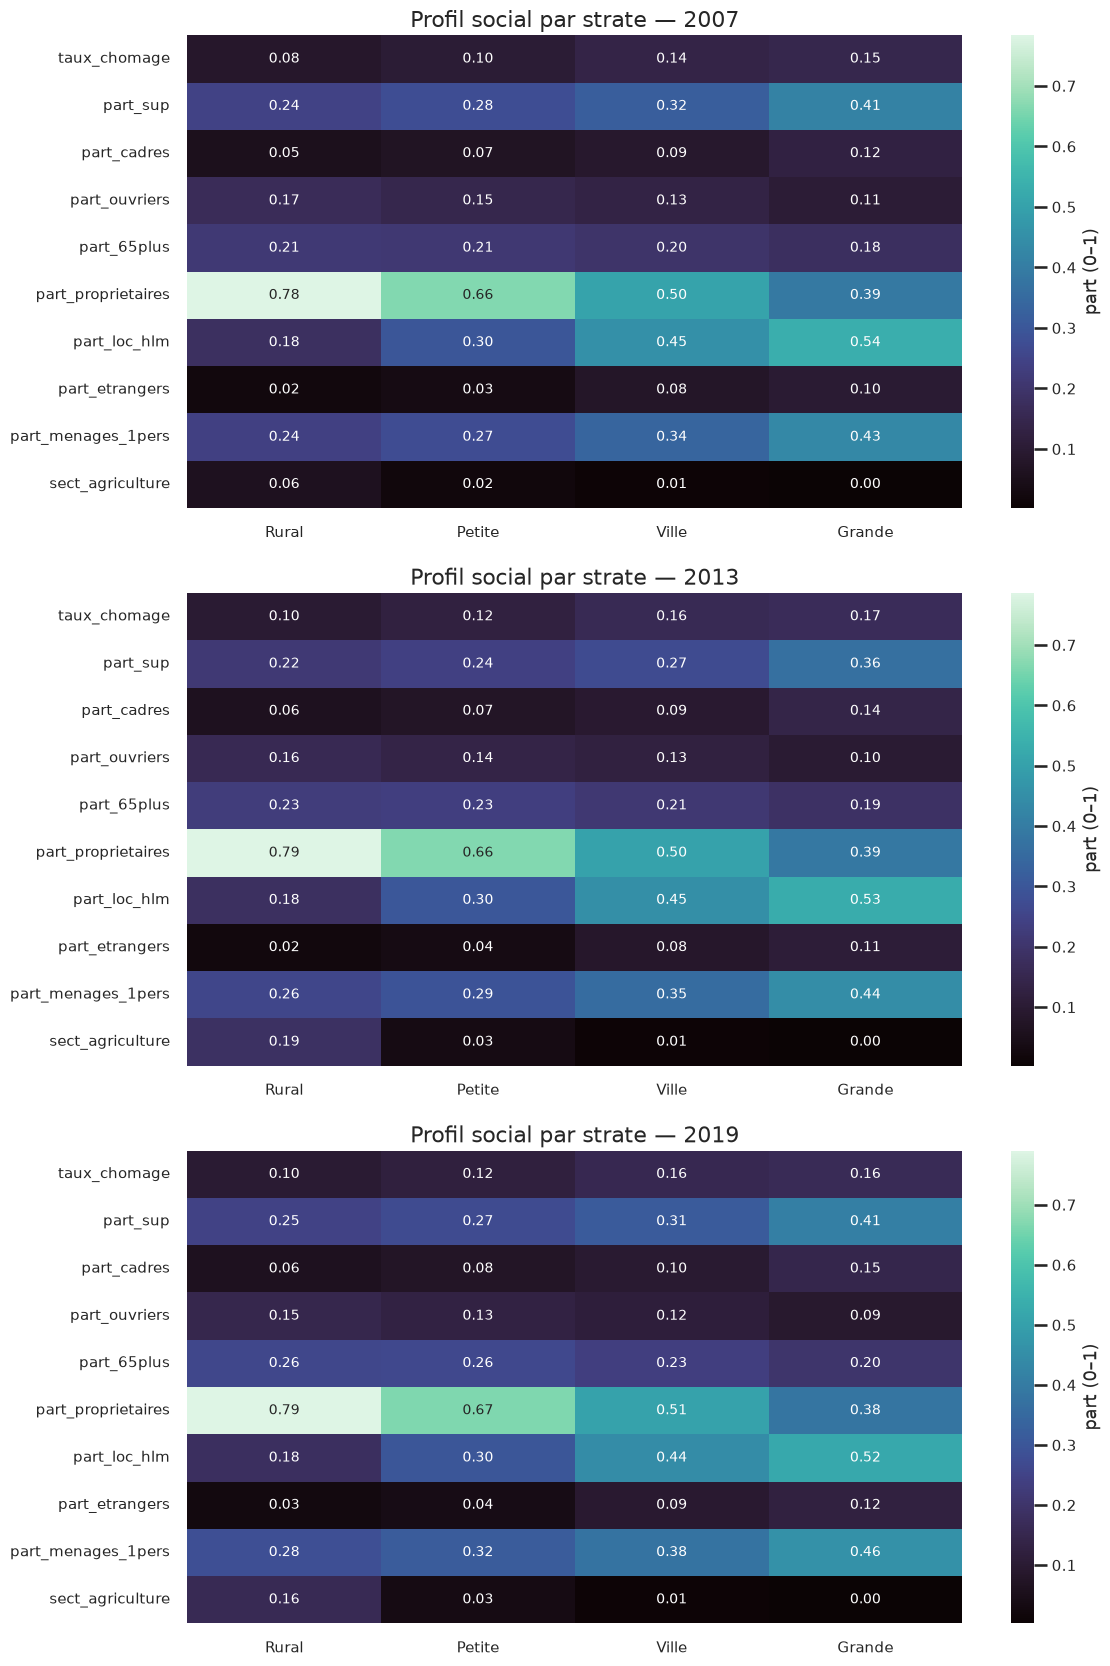

In [2]:
cols = ["taux_chomage","part_sup","part_cadres","part_ouvriers","part_65plus",
        "part_proprietaires","part_loc_hlm","part_etrangers","part_menages_1pers","sect_agriculture"]
fig, axes = plt.subplots(3, 1, figsize=(12, 17))
for ax, an in zip(axes, (2007, 2013, 2019)):
    sns.heatmap(eu.profil_strate(A[an], cols).T, annot=True, fmt=".2f", cmap=CMAP_SEQ,
                cbar_kws={"label": "part (0–1)"}, ax=ax, annot_kws={"size": 10})
    ax.set_title(f"Profil social par strate — {an}"); ax.set_xlabel("")
    ax.set_xticklabels([l.split()[0] for l in eu.STRATE_LABELS], rotation=0)
plt.tight_layout(); plt.show()

**Lecture.** Le gradient urbain/rural est le même aux trois dates : chômage, logement social, part
d'étrangers et personnes seules montent avec l'urbanité ; propriété et agriculture décroissent. La
structure territoriale est un **invariant** sur douze ans.

Corrélations entre variables (2019)

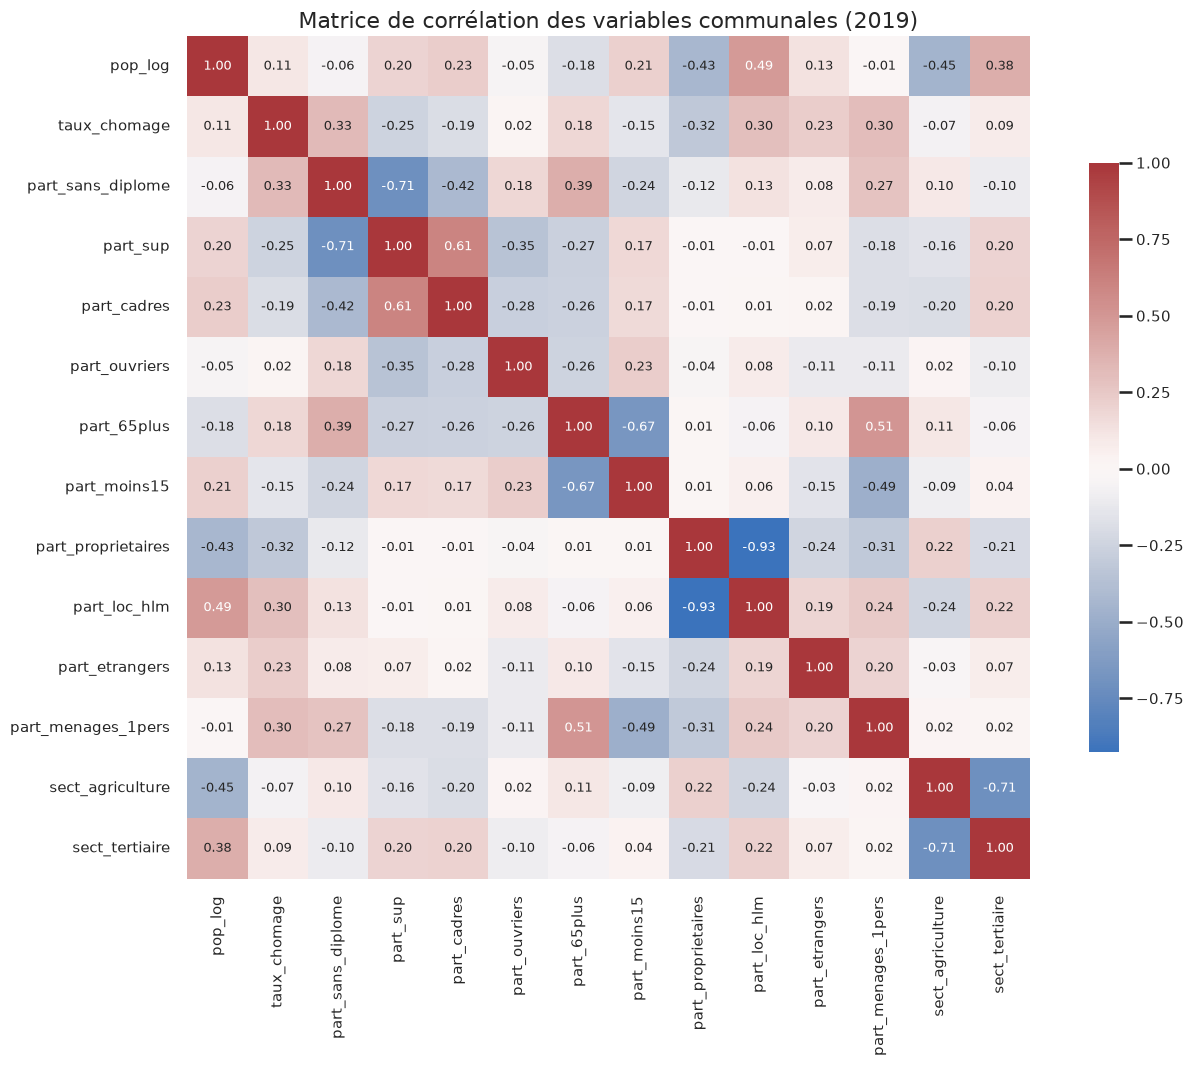

In [3]:
ac = ["pop_log","taux_chomage","part_sans_diplome","part_sup","part_cadres","part_ouvriers",
      "part_65plus","part_moins15","part_proprietaires","part_loc_hlm","part_etrangers",
      "part_menages_1pers","sect_agriculture","sect_tertiaire"]
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(A[2019][ac].corr(), annot=True, fmt=".2f", cmap=CMAP_CORR, center=0,
            square=True, cbar_kws={"shrink": .7}, ax=ax, annot_kws={"size": 9})
ax.set_title("Matrice de corrélation des variables communales (2019)")
plt.tight_layout(); plt.show()

**Trois axes de fracture** : socio-culturel (diplôme/cadres ↔ sans-diplôme/ouvriers), cycle de vie
(65+ ↔ moins de 15 ans), et statut résidentiel (propriété ↔ HLM, r ≈ −0,93). Ce sont les
déterminants classiques de la participation électorale.

Nuages de points — relations sociales clés (2019)
*Un graphe par relation, points colorés par strate.*

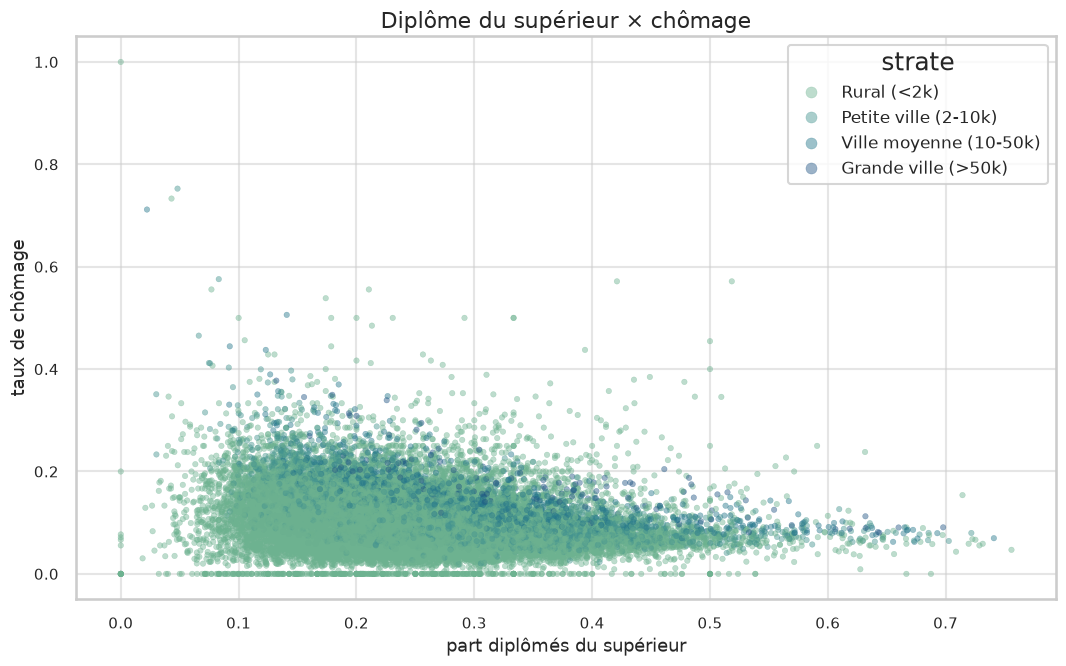

In [4]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=A[2019], x="part_sup", y="taux_chomage", hue="strate",
                palette=PAL_STRATE, s=16, alpha=.45, edgecolor=None, ax=ax)
ax.set_title("Diplôme du supérieur × chômage"); ax.set_xlabel("part diplômés du supérieur")
ax.set_ylabel("taux de chômage"); ax.legend(title="strate", markerscale=2)
plt.tight_layout(); plt.show()

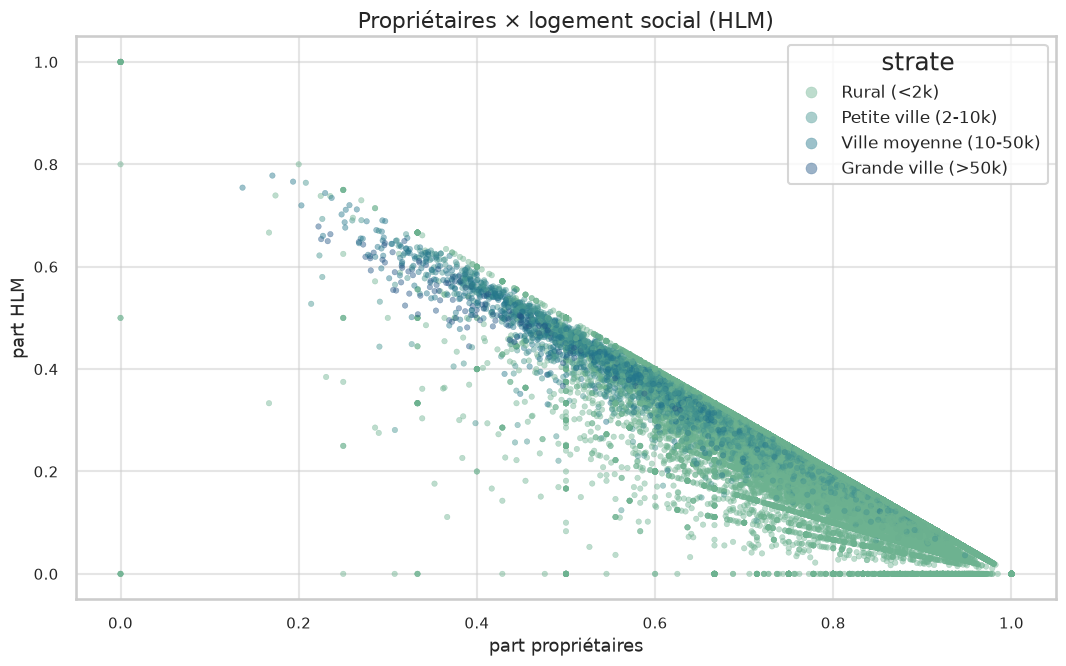

In [5]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=A[2019], x="part_proprietaires", y="part_loc_hlm", hue="strate",
                palette=PAL_STRATE, s=16, alpha=.45, edgecolor=None, ax=ax)
ax.set_title("Propriétaires × logement social (HLM)"); ax.set_xlabel("part propriétaires")
ax.set_ylabel("part HLM"); ax.legend(title="strate", markerscale=2)
plt.tight_layout(); plt.show()

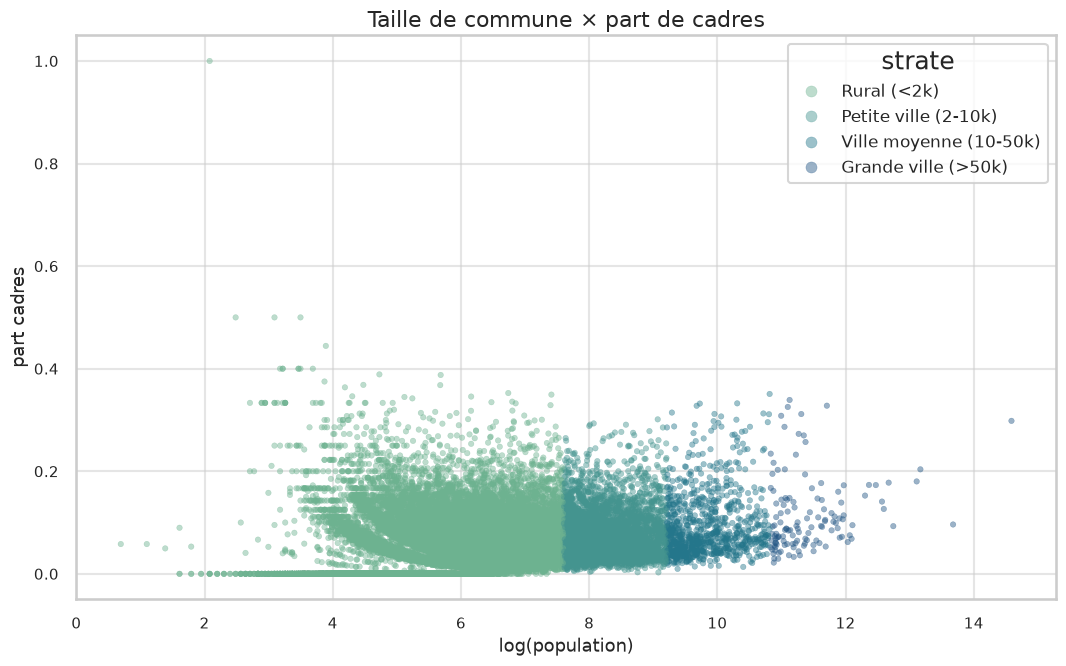

In [6]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=A[2019], x="pop_log", y="part_cadres", hue="strate",
                palette=PAL_STRATE, s=16, alpha=.45, edgecolor=None, ax=ax)
ax.set_title("Taille de commune × part de cadres"); ax.set_xlabel("log(population)")
ax.set_ylabel("part cadres"); ax.legend(title="strate", markerscale=2)
plt.tight_layout(); plt.show()

**Lecture.** Corrélation négative diplôme↔chômage ; opposition nette propriété↔HLM ; les cadres se
concentrent dans les grandes communes. Les strates se placent en gradient sur chaque nuage — le
territoire ordonne le social.

Typologie territoriale (k-means, 5 types — comparaison des trois années)

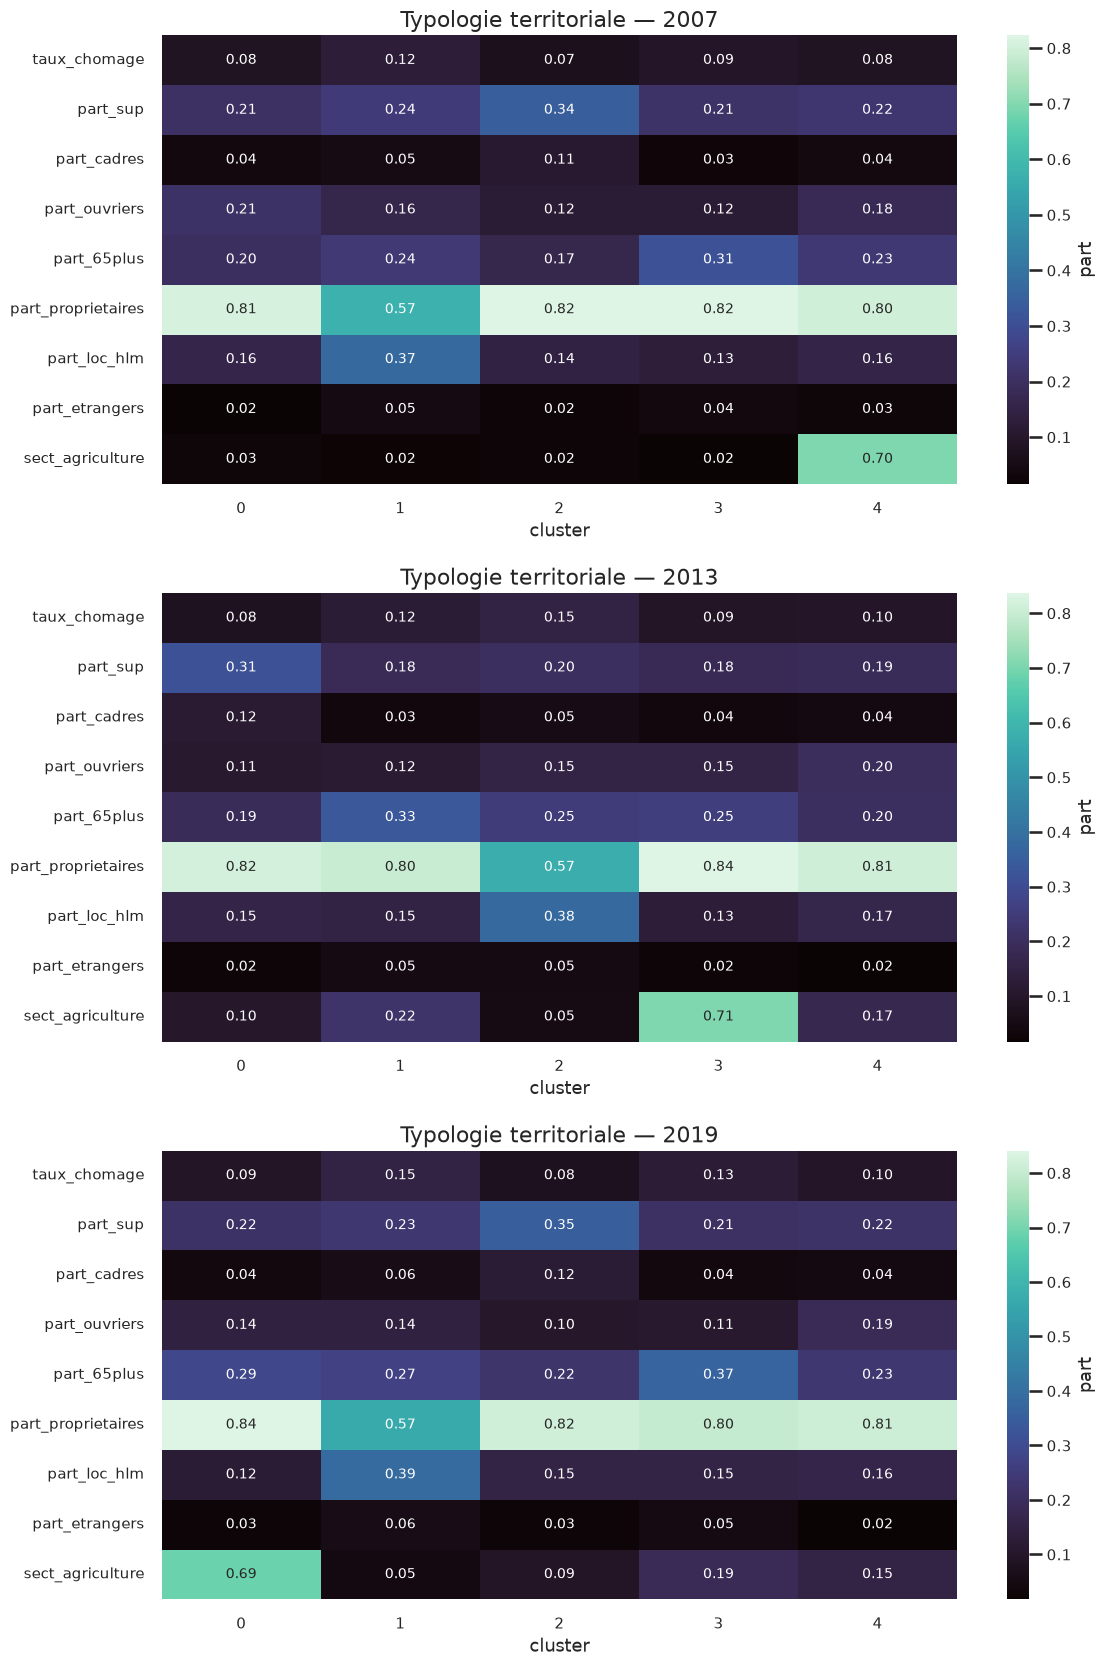

In [8]:
synth = ["taux_chomage","part_sup","part_cadres","part_ouvriers","part_65plus",
         "part_proprietaires","part_loc_hlm","part_etrangers","sect_agriculture"]
fig, axes = plt.subplots(3, 1, figsize=(12, 17))
for ax, an in zip(axes, (2007, 2013, 2019)):
    _, prof = eu.typologie(A[an], k=5)
    sns.heatmap(prof[synth].T, annot=True, fmt=".2f", cmap=CMAP_SEQ,
                cbar_kws={"label": "part"}, ax=ax, annot_kws={"size": 10})
    ax.set_title(f"Typologie territoriale — {an}"); ax.set_xlabel("cluster")
plt.tight_layout(); plt.show()

**Lecture.** Cinq types reviennent aux trois dates : rural agricole, périurbain favorisé, rural
vieillissant, rural ouvrier, petites villes/périphéries populaires. *La grille territoriale est
stable — réutilisable telle quelle pour le croisement électoral.* (Les numéros de cluster varient
d'un run à l'autre : identifier par le profil, pas par le numéro.)

Évolution des clivages (2007 → 2019)
Chômage par strate et par année

/tmp/ipykernel_17924/2962086890.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xlab, rotation=0); ax.legend(title="année")


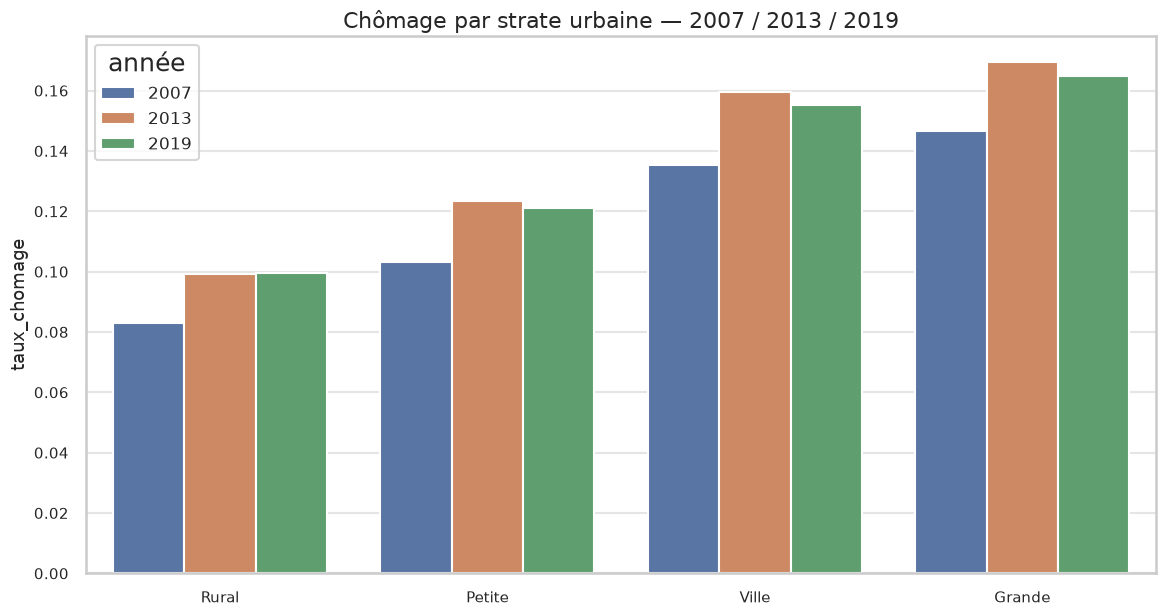

In [9]:
rows = []
for an in (2007, 2013, 2019):
    p = eu.profil_strate(A[an], cols).reset_index(); p["annee"] = an; rows.append(p)
T = pd.concat(rows, ignore_index=True)
xlab = [l.split()[0] for l in eu.STRATE_LABELS]

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.barplot(data=T, x="strate", y="taux_chomage", hue="annee", palette=PAL_ANNEES, ax=ax)
ax.set_title("Chômage par strate urbaine — 2007 / 2013 / 2019"); ax.set_xlabel("")
ax.set_xticklabels(xlab, rotation=0); ax.legend(title="année")
plt.tight_layout(); plt.show()

Logement social (HLM) par strate et par année

/tmp/ipykernel_17924/3944274795.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xlab, rotation=0); ax.legend(title="année")


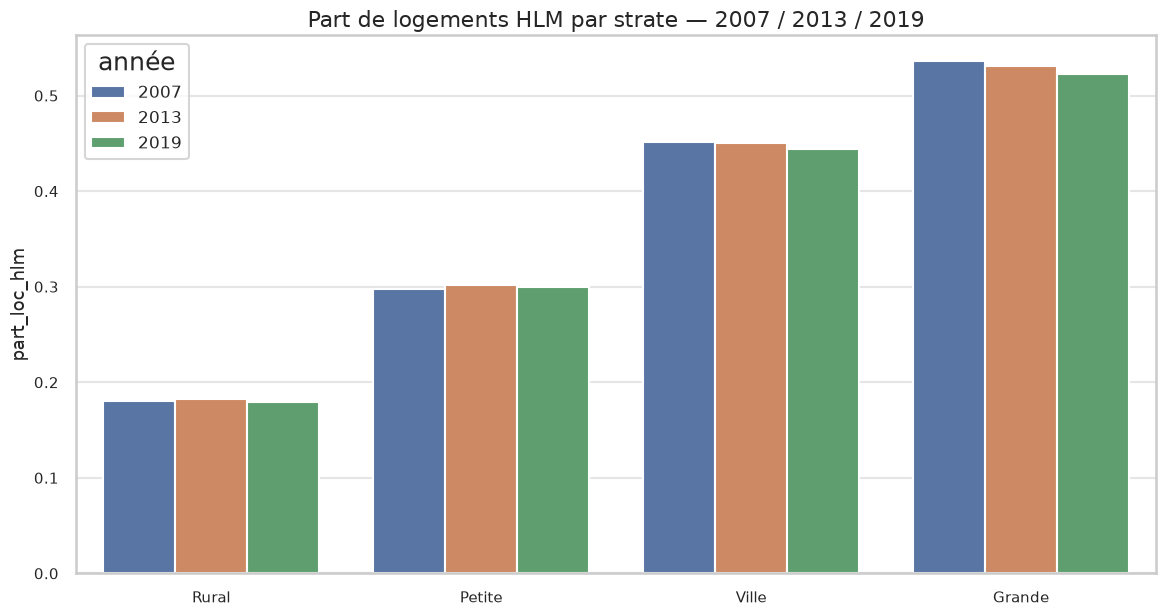

In [10]:
fig, ax = plt.subplots(figsize=(12, 6.5))
sns.barplot(data=T, x="strate", y="part_loc_hlm", hue="annee", palette=PAL_ANNEES, ax=ax)
ax.set_title("Part de logements HLM par strate — 2007 / 2013 / 2019"); ax.set_xlabel("")
ax.set_xticklabels(xlab, rotation=0); ax.legend(title="année")
plt.tight_layout(); plt.show()

Part d'étrangers par strate et par année

/tmp/ipykernel_17924/3777418177.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xlab, rotation=0); ax.legend(title="année")


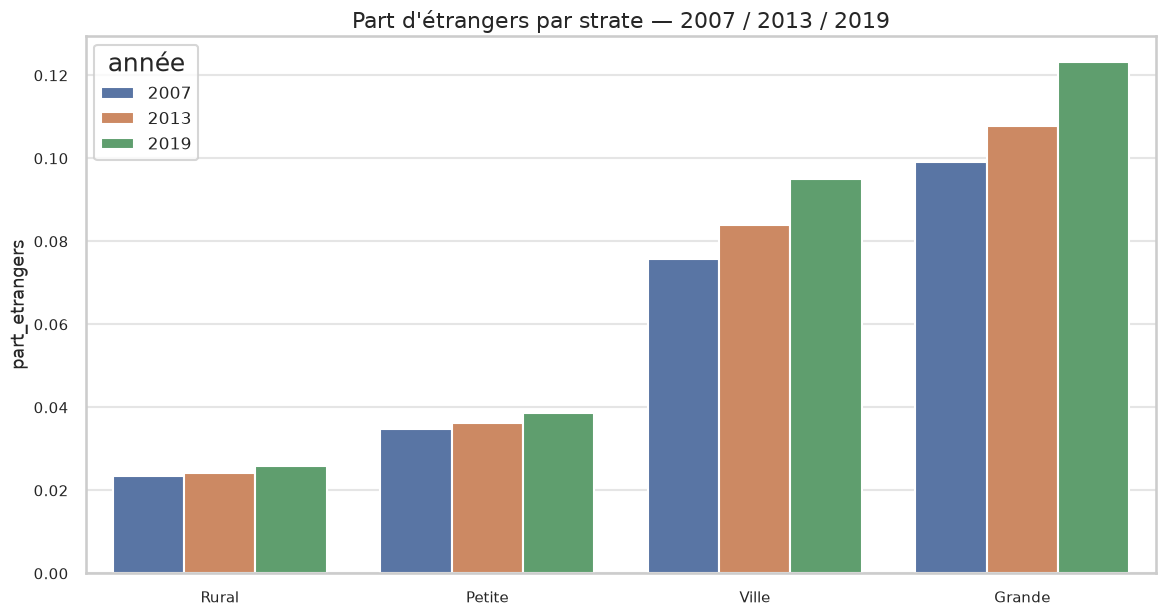

In [11]:
fig, ax = plt.subplots(figsize=(12, 6.5))
sns.barplot(data=T, x="strate", y="part_etrangers", hue="annee", palette=PAL_ANNEES, ax=ax)
ax.set_title("Part d'étrangers par strate — 2007 / 2013 / 2019"); ax.set_xlabel("")
ax.set_xticklabels(xlab, rotation=0); ax.legend(title="année")
plt.tight_layout(); plt.show()

Intensité du clivage urbain/rural dans le temps

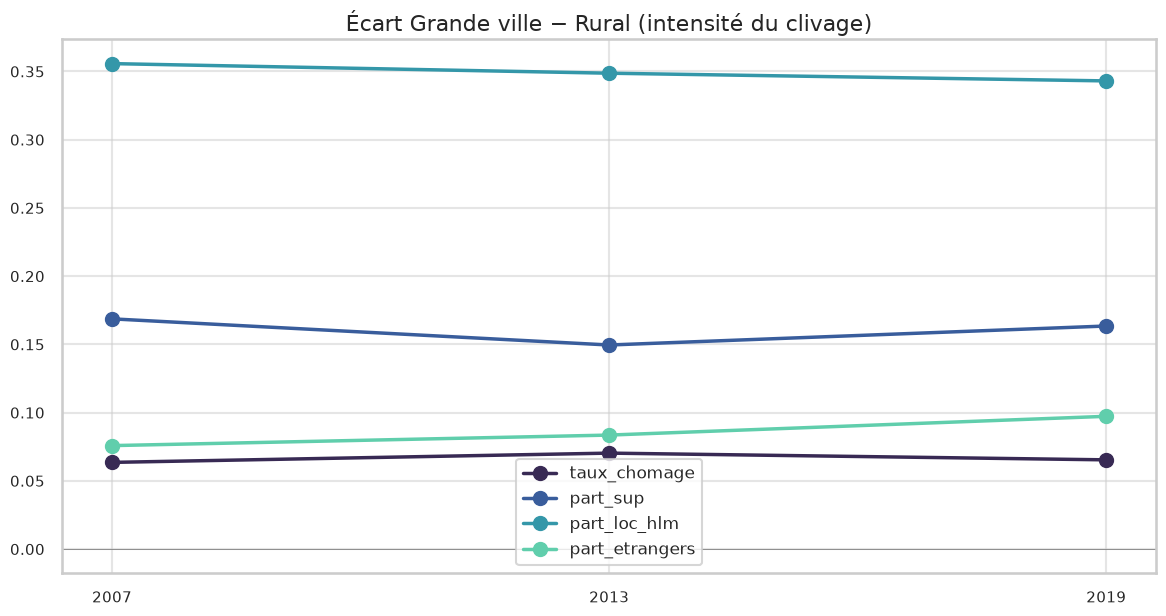

annee,2007,2013,2019
taux_chomage,0.064,0.070,0.065
part_sup,0.169,0.150,0.163
part_loc_hlm,0.356,0.349,0.343
part_etrangers,0.076,0.084,0.097


In [12]:
gv, ru = eu.STRATE_LABELS[3], eu.STRATE_LABELS[0]
E = pd.DataFrame({c: (T.pivot(index="strate", columns="annee", values=c).loc[gv]
                      - T.pivot(index="strate", columns="annee", values=c).loc[ru])
                  for c in ["taux_chomage", "part_sup", "part_loc_hlm", "part_etrangers"]}).T

fig, ax = plt.subplots(figsize=(12, 6.5))
for c, col in zip(E.index, sns.color_palette("mako", len(E))):
    ax.plot([2007, 2013, 2019], E.loc[c], marker="o", linewidth=2.5, markersize=10, color=col, label=c)
ax.set_title("Écart Grande ville − Rural (intensité du clivage)")
ax.set_xticks([2007, 2013, 2019]); ax.axhline(0, color="grey", lw=.6); ax.legend()
plt.tight_layout(); plt.show()
display(E.round(3))

**Interprétation.** Le clivage est stable sur le chômage, le diplôme et le logement social ; il se
**creuse sur la part d'étrangers** (les grandes villes se diversifient plus vite) — polarisation
territoriale à surveiller.

Stabilité du chômage communal (2007 vs 2019)

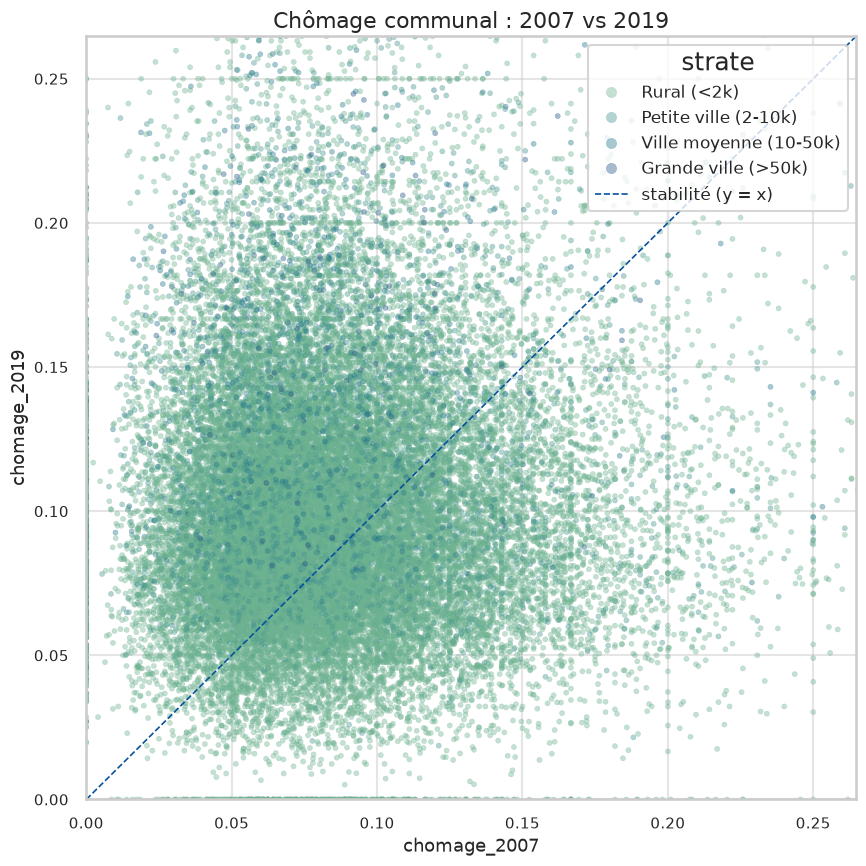

Corrélation chômage 2007↔2019 : 0.04


In [13]:
communes = A[2007].index.intersection(A[2019].index)
comp = pd.DataFrame({"chomage_2007": A[2007].loc[communes, "taux_chomage"],
                     "chomage_2019": A[2019].loc[communes, "taux_chomage"],
                     "strate":       A[2019].loc[communes, "strate"]})
fig, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(data=comp, x="chomage_2007", y="chomage_2019", hue="strate",
                palette=PAL_STRATE, s=14, alpha=.4, edgecolor=None, ax=ax)
lims = [0, comp[["chomage_2007", "chomage_2019"]].quantile(.99).max()]
ax.plot(lims, lims, color="#08519c", lw=1.2, ls="--", label="stabilité (y = x)")
ax.set_xlim(lims); ax.set_ylim(lims); ax.legend(title="strate", markerscale=2)
ax.set_title("Chômage communal : 2007 vs 2019")
plt.tight_layout(); plt.show()
print("Corrélation chômage 2007↔2019 :", round(comp['chomage_2007'].corr(comp['chomage_2019']), 2))

Vulnérabilité à l'abstention par strate et par année

/tmp/ipykernel_17924/3516106423.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xlabel(""); ax.set_xticklabels(xlab, rotation=0); ax.legend(title="année")


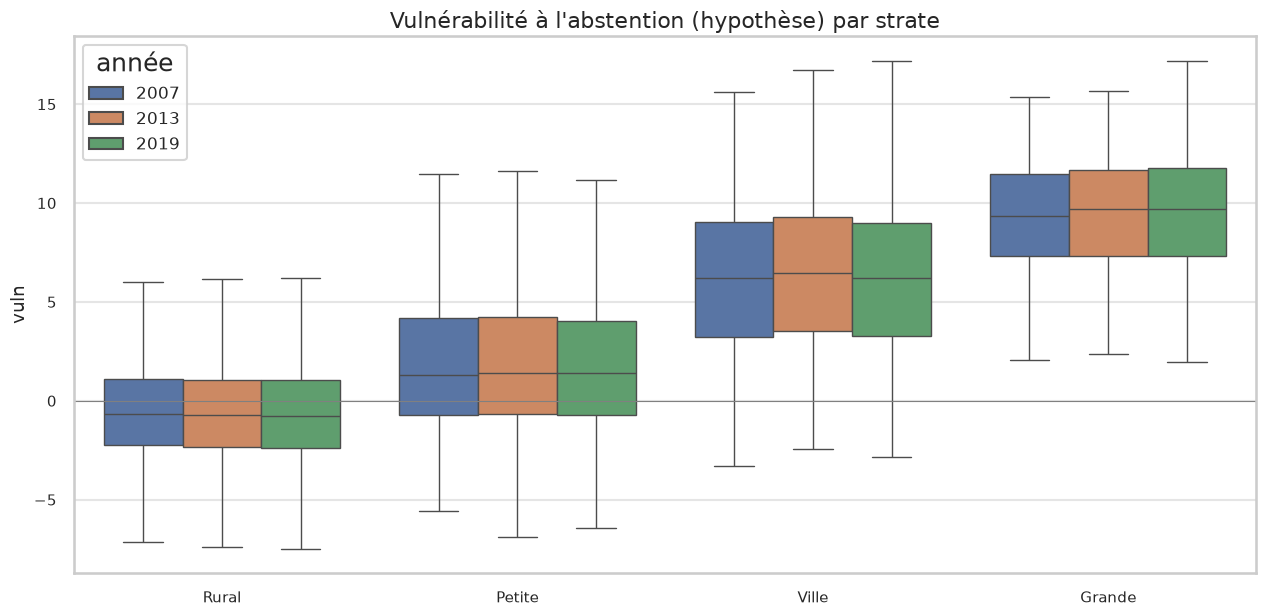

In [14]:
rows = []
for an in (2007, 2013, 2019):
    d = A[an].copy(); d["vuln"] = eu.indice_vulnerabilite_abstention(d); d["annee"] = an
    rows.append(d[["strate", "vuln", "annee"]])
V = pd.concat(rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 6.5))
sns.boxplot(data=V, x="strate", y="vuln", hue="annee", palette=PAL_ANNEES, showfliers=False, ax=ax)
ax.axhline(0, color="grey", lw=.8); ax.set_title("Vulnérabilité à l'abstention (hypothèse) par strate")
ax.set_xlabel(""); ax.set_xticklabels(xlab, rotation=0); ax.legend(title="année")
plt.tight_layout(); plt.show()

Synthèse & prochaine étape

- Clivage urbain/rural et cinq types de territoires : **structure sociale persistante** sur douze ans.
- Seule la **diversité d'origine** polarise davantage villes et campagnes.
- Gradient de **vulnérabilité à l'abstention** (périphéries populaires > rural âgé) stable dans le temps.

**Étape suivante** : joindre `data/raw/Resultat/` par `CODGEO` (municipales 2008↔2007, 2014↔2013,
2020↔2019), calculer le **taux d'abstention** communal, puis tester chaque hypothèse et vérifier si
les liens tiennent aux **trois scrutins** (effet structurel vs conjoncturel).